# Báo cáo bài tập Chủ đề 1: Linear Regression


## Mục lục

1. [Bài 1 - Hồi quy tuyến tính đơn](#1-bài-1)
2. [Bài 2 - SSE và R²](#2-bài-2)
3. [Bài 3 - Normal Equation](#3-bài-3)
4. [Bài 4 - Gradient Descent](#4-bài-4)
5. [Bài 5 - Chuẩn hóa dữ liệu](#5-bài-5)
6. [Bài 6 - MSE và Huber Loss](#6-bài-6)
7. [Bài 7 - Ridge Regression](#7-bài-7)
8. [Bài 8 - Lasso và Feature Selection](#8-bài-8)
9. [Bài 9 - Bias và Variance](#9-bài-9)
10. [Bài 10 - Training và Validation Loss](#10-bài-10)
11. [Bài 11 - Learning Rate](#11-bài-11)
12. [Bài 12 - Learning Curve](#12-bài-12)
13. [Bài 13 - Auto-tuning Learning Rate](#13-bài-13)
14. [Bài 14 - Lựa chọn hệ số Ridge](#14-bài-14)
15. [Bài 15 - So sánh các hàm mất mát](#15-bài-15)
16. [Bài 16 - Hình dáng Huber Loss](#16-bài-16)
17. [Bài 17 - L1 và L2 Regularization](#17-bài-17)
18. [Bài 18 - Vai trò của λ](#18-bài-18)
19. [Bài 19 - OLS và HuberRegressor](#19-bài-19)
20. [Bài 20 - Lasso Feature Selection](#20-bài-20)

---
### 1. Bài 1

Cho tập dữ liệu quan sát về số năm kinh nghiệm $x$ và mức lương ($y$ - đơn vị: triệu đồng) của 4 kỹ sư như sau:

- $(1,10)$, $(2,15)$, $(3,18)$, $(4,25)$

#### Chuẩn bị dữ liệu bằng Python

In [191]:
x = [1, 2, 3, 4]  # year of experiences
y = [10, 15, 18, 25]  # corresponding salaries

#### 1.1. Tính các giá trị trung bình $\bar{x}$ và $\bar{y}$

In [192]:
x_total = 0
y_total = 0

for i in range(0, 4, 1):
    x_total += x[i]
    y_total += y[i]

x_avg = x_total / 4
y_avg = y_total / 4

print(f"x̄ = {x_avg:.2f}")
print(f"ȳ = {y_avg:.2f}")

x̄ = 2.50
ȳ = 17.00


#### 1.2. Tìm phương trình hồi quy tuyến tính dạng $\hat{y}=w_1x+w_0$ bằng cách tính trực tiếp các hệ số theo công thức

$$w_1=\frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2}$$

$$w_0=\bar{y}-w_1\bar{x}$$

In [193]:
# Tính các hệ số w1 và w0
num = 0
denom = 0

for i in range(0, 4, 1):
    num += (x[i] - x_avg) * (y[i] - y_avg)
    denom += (x[i] - x_avg) * (x[i] - x_avg)

w1 = num / denom
w0 = y_avg - w1 * x_avg

def model(input_value):
    return w1 * input_value + w0

print(f"w1 = {w1:.2f}")
print(f"w0 = {w0:.2f}")
print(f"ŷ = {w1:.2f}x + {w0:.2f}")

w1 = 4.80
w0 = 5.00
ŷ = 4.80x + 5.00


#### 1.3. Dự báo mức lương của một kỹ sư có 5 năm kinh nghiệm

In [194]:
yoe_5_salary = model(5)

print(f"ŷ(5) = {yoe_5_salary:.2f} triệu đồng")

ŷ(5) = 29.00 triệu đồng


---
### 2. Bài 2

Sử dụng mô hình tìm được ở Bài 1:


#### 2.1. Tính giá trị dự báo $\hat{y}_i$ cho từng điểm dữ liệu $x_i\in\{1,2,3,4\}$

In [195]:
y_pred: list[float] = []

for i in range(1, 5, 1):
    y_pred.append(model(i))
    
for x_value, predicted_value in zip(x, y_pred):
    print(f"x = {x_value}: ŷ = {predicted_value:.2f}")

x = 1: ŷ = 9.80
x = 2: ŷ = 14.60
x = 3: ŷ = 19.40
x = 4: ŷ = 24.20


#### 2.2. Tính tổng bình phương sai số thặng dư (SSE - Sum of Squared Errors)

Công thức:

$$SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

In [196]:
SSE = 0

for i in range(0,4,1):
  SSE += (y[i] - y_pred[i])*(y[i] - y_pred[i])
  
print(f"SSE = {SSE:.2f}")

SSE = 2.80


#### 2.3. Tính hệ số xác định $R^2$ biết rằng tổng bình phương tổng thể ($SST=\sum(y_i-\bar{y})^2$) của tập dữ liệu này là 115. Giải thích ý nghĩa của con số $R^2$ tìm được

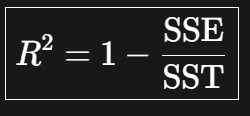

In [197]:
SST = 115

R2 = 1 - SSE/SST

print(f"R² = {R2}")

R² = 0.9756521739130435


#### a. Giải thích ý nghĩa con số $R^2$ tìm được

$R^2 \approx 0.9757$ nghĩa là mô hình hồi quy giải thích được khoảng **97,57% sự biến thiên của mức lương**, còn khoảng **2,43%** chưa được mô hình giải thích.

---
### 3. Bài 3 - Normal Equation

Cho bài toán hồi quy đa biến với ma trận đặc trưng $X$ (đã thêm cột bias bằng 1) và vector mục tiêu $y$:

$$X = \begin{bmatrix}1&0\\1&1\\1&2\end{bmatrix}, \qquad y = \begin{bmatrix}1\\3\\4\end{bmatrix}$$

Sử dụng công thức Normal Equation:

$$w=(X^TX)^{-1}X^Ty$$

để tìm vector trọng số $w=[w_0,w_1]^T$.





In [198]:
import numpy as np

X = np.array([[1, 0], [1, 1], [1, 2]])
Y = np.array([1, 3, 4])

w = np.linalg.inv(X.T @ X) @ X.T @ Y

print(f"w =[w_0, w_1]^T = {w}")

w =[w_0, w_1]^T = [1.16666667 1.5       ]


---
### 4. Bài 4 - Gradient Descent

Giả sử ta có hàm mất mát (Loss function) cho một tham số $w$:

$$J(w)=(3w-6)^2$$

Ta muốn tìm $w$ để $J(w)$ nhỏ nhất bằng thuật toán Gradient Descent.


#### 4.1. Tính đạo hàm (Gradient) $\dfrac{dJ}{dw}$


In [199]:
import sympy as sp

w_syms = sp.symbols('w')

J = (3 * w_syms - 6) * (3 * w_syms - 6)

dJ_dw = sp.diff(J, w_syms)

print("J(w) =", J)
print("dJ/dw =", dJ_dw)

J(w) = (3*w - 6)**2
dJ/dw = 18*w - 36


#### 4.2. Giả sử giá trị khởi tạo $w^{(0)}=0$ và tốc độ học (learning rate) $\eta=0.05$. Hãy tính giá trị của $w$ sau 2 bước cập nhật ($w^{(1)}$ và $w^{(2)}$)

Công thức cập nhật:

$$w^{(k+1)}=w^{(k)}-\eta\frac{dJ}{dw}\left(w^{(k)}\right)$$


In [200]:
learning_rate = 0.05
w = 0

for i in range(0, 2, 1):
    w = w - learning_rate * dJ_dw.subs(w_syms, w)
    print(f"w({i+1}) = {w:.4f}")

w(1) = 1.8000
w(2) = 1.9800


#### 4.3. Giá trị $w$ sẽ hội tụ về bao nhiêu nếu số bước lặp tiến đến vô cùng?

Khi $w$ hội tụ thì giá trị của nó không thay đổi nữa:

$$w^{(k+1)}=w^{(k)}=w$$

Thay vào công thức cập nhật:

$$w=w-0.05(18w-36)$$

$$18w-36=0$$

Vậy:

$$\boxed{w=2}$$

Kiểm tra lại bằng code:


In [201]:
w = 0

for _ in range(100):
    w = w - learning_rate * dJ_dw.subs(w_syms, w)

print(f"w ≈ {w:.4f}")

w ≈ 2.0000


---
### 5. Bài 5 - Chuẩn hóa dữ liệu

Một kỹ sư đang xây dựng mô hình dự báo giá nhà dựa trên diện tích ($x_1$ tính theo m², khoảng 50–500) và số phòng ngủ ($x_2$, khoảng 1–5).

#### 5.1. Tại sao việc sử dụng trực tiếp dữ liệu này vào Gradient Descent có thể khiến thuật toán hội tụ rất chậm?


```md
Khi các dữ liệu đặc trưng (ở đây là diện tích và số phòng ngủ) không có cùng đơn vị đo và chênh lệch lớn về độ lớn, Gradient Descent sẽ cập nhật 2 trọng số (w1 và w2) với mức rất khác nhau và có thể đi zigzag.

Việc lựa chọn learning rate phù hợp cho cả 2 đại lượng sẽ khó hơn, khiến Gradient Descent hội tụ chậm.
```


#### 5.2. Hãy thực hiện chuẩn hóa dữ liệu (Standardization/Z-score Normalization) cho điểm dữ liệu có diện tích $x=100$ m². Biết rằng trong tập dữ liệu, diện tích trung bình $\mu=150$ m² và độ lệch chuẩn $\sigma=50$ m². Công thức:

$$z=\frac{x-\mu}{\sigma}$$



> Thay các giá trị vào công thức:
>
> $$z=\frac{100-150}{50}=-1$$
>
> Giá trị $z=-1$ nghĩa là diện tích 100 m² thấp hơn giá trị trung bình 1 độ lệch chuẩn.


In [202]:
def calc_z(x, mu, sigma):
    return (x - mu) / sigma
  
print("z =", calc_z(100, 150, 50))

z = -1.0


---
### 6. Bài 6 - MSE và Huber Loss

Trong môi trường công nghiệp, cảm biến nhiệt độ PT100 có thể gặp nhiễu đột biến (outliers) do can nhiễu điện từ từ động cơ. Ta có tập dữ liệu ADC đọc về ($x$) và nhiệt độ thực tế ($y$).

Giả sử tại một thời điểm, dữ liệu bị nhiễu nặng: $x=[10,20,30,100]$, $y=[15,25,35,200]$ (điểm cuối là nhiễu).

#### 6.1. Nếu dùng MSE, sai số tại điểm nhiễu $(100-200)^2=10000$ sẽ ảnh hưởng thế nào đến đường hồi quy?



Do sai số được lũy thừa lên nên một điểm nhiễu có error rất lớn sẽ ảnh hướng nhiều vào MSE. Nếu như trong quá trình train model, MSE được sử dụng để làm tiêu chí đánh giá thì quá trình train sẽ điều chỉnh đường hồi quy mạnh về điểm nhiễu, khiến cho sai số dự đoán các điểm thực tiếp theo bị sai lệch đi.

#### 6.2. Tại sao việc áp dụng Huber Loss với ngưỡng $\delta=1.0$ lại giúp đường hồi quy bền vững hơn trước điểm nhiễu $y=200$?

1. Huber Loss giúp việc giới hạn ảnh hưởng của nhiễu đến sai số hệ thống bằng cách linh hoạt việc tính toán sai số (MSE với sai số bình thường và MAE với sai số của nhiễu).
2. Đối với ứng dụng này, nhiệt độ môi thường giao động nhỏ, nhất là khi tần số lấy mẫu của cảm biến lớn (ví dụ như 20Hz). Việc lựa chọn mốc $\delta=1$ là một mức hợp lí để phân biệt thay đổi thật và nhiễu môi trường.


---
### 7. Bài 7 - Ridge Regression

Bạn đang phát triển một thiết bị Edge AI chạy pin. Mức tiêu thụ dòng điện ($y$) phụ thuộc vào xung nhịp CPU ($x_1$), số lượng nhân NPU hoạt động ($x_2$) và độ sáng màn hình ($x_3$). Do thiết kế phần cứng, $x_1$ và $x_2$ có tương quan rất mạnh với nhau.

#### 7.1. Tại sao khi sử dụng OLS thông thường, các hệ số trọng số $w_1,w_2$ có thể trở nên rất lớn và mất ổn định?



Bởi vì w1 và w2 có xu hướng thay đổi và ảnh hưởng gần giống nhau. Khi đó đó việc điều chỉnh dựa trên OLS thông thường sẽ có xu hướng như tăng w1, giảm w2 mà tổng dự đoán vẫn sẽ tương đối đúng. Điều này khiến cho việc w1 và w2 được điều chỉnh lớn và có thể ảnh hưởng bù trừ (ví dụ w1 = 100, w2= -95), dẫn đến tình trạng model bị overfitting.



#### 7.2. Nếu thêm thành phần chính quy hóa L2 ($\lambda\sum w_i^2$), hãy giải thích cơ chế giúp ma trận $(X^TX+\lambda I)$ luôn có thể nghịch đảo được, từ đó ổn định hệ số hồi quy



Khi x1 và x2 tương quan mạnh, các cột trong X gần phụ thuộc tuyến tính. Khi đó ma trận X^T X có thể có định thức bằng 0 hoặc rất gần 0, làm cho việc tính nghịch đảo không thực hiện được hoặc kết quả không ổn định.

Khi thêm lambda I, giá trị lambda sẽ được cộng vào các phần tử trên đường chéo của X^T X. Với lambda > 0, các giá trị riêng của ma trận cũng được cộng thêm lambda nên sẽ lớn hơn 0. Vì vậy định thức của ma trận khác 0 và ma trận có thể nghịch đảo được.

Ngoài ra, thành phần L2 còn phạt các hệ số có giá trị quá lớn, khiến cho w1 và w2 nhỏ hơn và ít bị thay đổi mạnh khi dữ liệu có nhiễu.




#### 7.3. Nếu bạn muốn hy sinh một chút độ chính xác trên tập training để mô hình hoạt động ổn định hơn trên các thiết bị phần cứng khác nhau (Generalization), bạn sẽ tăng hay giảm $\lambda$?



>Việc thay đổi $\lambda$ sẽ có xu hướng như sau:
>1. Tăng: các hệ số w được điều chỉnh nhỏ hơn, dẫn đến ít nhạy hơn với dữ liệu training và với nhiễu. Khiến model kém chính xác hơn với dữ liệu training và ít nhạy hơn với dữ liệu nhiễu.
>2. Giảm: model nhạy hơn với các dữ liệu training và nhiễu. Khiến model chính xác hơn nhưng bị ảnh hưởng bởi nhiễu nhiều hơn.
>
>Dựa trên quan sát trên, việc tăng $\lambda$ sẽ giúp model ít phụ thuộc vào dữ liệu được train và ổn định hơn trên các thiết bị phần cứng khác nhau.





---
### 8. Bài 8 - Lasso và Feature Selection

Một bo mạch giám sát sức khỏe động cơ thu thập 10 loại tín hiệu khác nhau (rung động, âm thanh, từ trường, nhiệt độ...). Tuy nhiên, tài nguyên tính toán của MCU có hạn, bạn chỉ muốn chọn ra 3–4 đặc trưng quan trọng nhất để chạy mô hình dự báo lỗi.

#### 8.1. Giải thích tại sao khi tăng tham số phạt $\lambda$ trong Lasso, các hệ số $w$ của các đặc trưng ít quan trọng sẽ bị triệt tiêu về đúng bằng 0



>Dựa vào công thức của Lasso Regression, mức độ phạt không giảm sâu khi thay đổi trọng số. Các đặc trưng ít quan trọng sau các lần thay đổi vẫn sẽ tiếp tục bị phạt ở một mức cố định, cho tới khi đặc trưng bị loại hoàn toàn.




#### 8.2. So sánh ưu điểm của Lasso so với việc dùng tay thử sai từng tổ hợp biến trong bài toán có rất nhiều cảm biến đầu vào



>Lasso có khả năng giảm và loại hoàn toàn ảnh hưởng của những đặc trưng ít đóng góp cho model, trong khi việc lựa chọn bằng tay trên bài toán có rất nhiều biến đầu vào tốn nhiều thời gian.



---
### 9. Bài 9 - Bias và Variance

Bạn đang làm hệ thống Adaptive GPS weighting cho robot. Mô hình Multilayer Perceptron (hoặc Linear Regression bậc cao) của bạn đạt sai số gần như bằng 0 trên tập dữ liệu đã thu thập ở văn phòng, nhưng khi đem ra thực địa (đường phố nhiều nhà cao tầng), sai số lại nhảy vọt.

#### 9.1. Đây là hiện tượng High Bias hay High Variance?



> Đây là high variance vì model đã được tạo thành nhiều ràng buộc bởi data ở văn phòng. Điều đó khiến model có sai số thấp với tệp đã train nhưng quá nhạy với dữ liệu training và kém chính xác với những tệp data khác.



#### 9.2. Đề xuất 2 giải pháp kỹ thuật để khắc phục




> 1. Giảm variance bằng cách giảm độ phức tạp của mô hình. Áp dụng phương pháp Ridge hoặc Lasso Regression để giảm tầm ảnh hưởng của các dữ liệu đặc trưng kém quan trọng.
> 2. Đa dạng hóa tệp dữ liệu train bằng cách thu thập thêm dữ liệu thực địa. Áp dụng các phương pháp preprocessing để đảm bảo tính ngẫu nhiên và chuẩn hóa của data trước khi train.




---
### 10. Bài 10 - Training và Validation Loss

Giả sử bạn đang huấn luyện một mô hình hồi quy để dự báo nhiệt độ của một chip vi điều khiển dựa trên xung nhịp CPU và điện áp cấp. Đồ thị dưới đây biểu diễn giá trị hàm mất mát (Loss - tính bằng MSE) trên tập Training (màu xanh) và tập Validation (màu cam) sau 100 kỷ nguyên (Epochs).

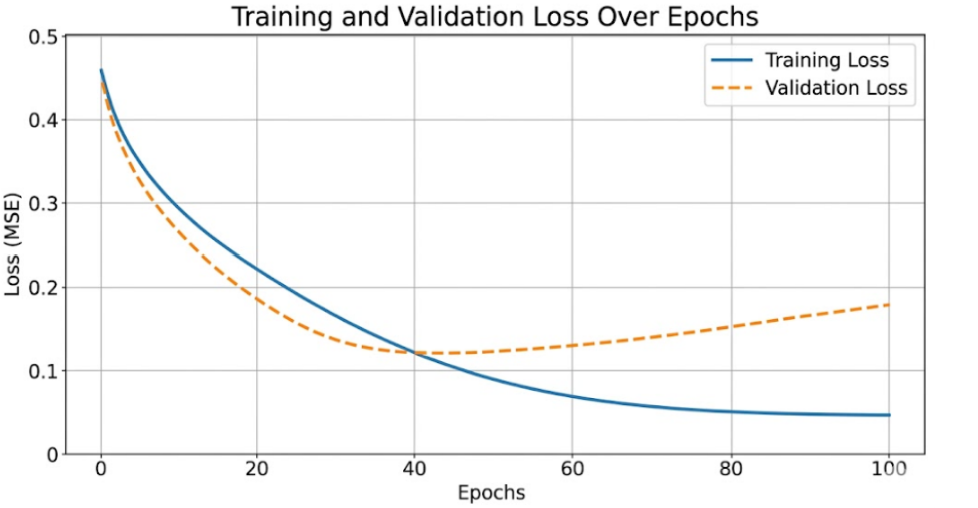

Dựa trên đồ thị, hãy trả lời các câu hỏi sau:

#### 10.1. Quan sát hình dáng của hai đường cong. Tại sao Training Loss tiếp tục giảm về gần 0 trong khi Validation Loss bắt đầu tăng lại sau Epoch thứ 40? Hiện tượng này gọi là gì và giải thích cơ chế của nó?



> Đây là hiện tượng overfit training data, nghĩ là model bắt đầu thích nghi nhiều hơn với tệp data dùng train và kém chính xác hơn với tệp data dùng để verify.



#### 10.2. Trong bối cảnh triển khai mô hình lên hệ thống nhúng có tài nguyên hạn chế, bạn sẽ chọn phiên bản mô hình ở Epoch nào (ví dụ: Epoch 20, Epoch 40, hay Epoch 80) để nạp vào chip? Giải thích lựa chọn của bạn dựa trên yêu cầu về độ chính xác và khả năng tổng quát hóa (generalization)



> Model được lựa chọn sẽ là model có điểm validation loss nhỏ nhất (trong model này là Epoch 40). Tại đây, validation loss thấp nhất, giúp dự đoán tốt nhất đối với các data khác ngoài tệp dùng để train.


#### 10.3. Đề xuất ít nhất hai giải pháp kỹ thuật (về dữ liệu hoặc tham số) để giúp hai đường cong này nằm sát nhau hơn trong các lần huấn luyện sau



> 1. Tăng độ đa dạng và ngẫu nhiên của tệp data để train và validation. Điều này giúp cải thiện khả năng tổng quát hóa
> 2. Sử dụng Ridge hoặc Lasso regression để làm mô hình đơn giản hơn.


---
### 11. Bài 11 - Learning Rate

Một kỹ sư nhúng khác đang hiệu chuẩn cảm biến gia tốc (accelerometer) bằng Gradient Descent. Đồ thị dưới đây so sánh diễn biến của hàm mất mát (Loss) theo số bước lặp (Iterations) dưới 3 kịch bản khác nhau của Learning Rate $\eta$.

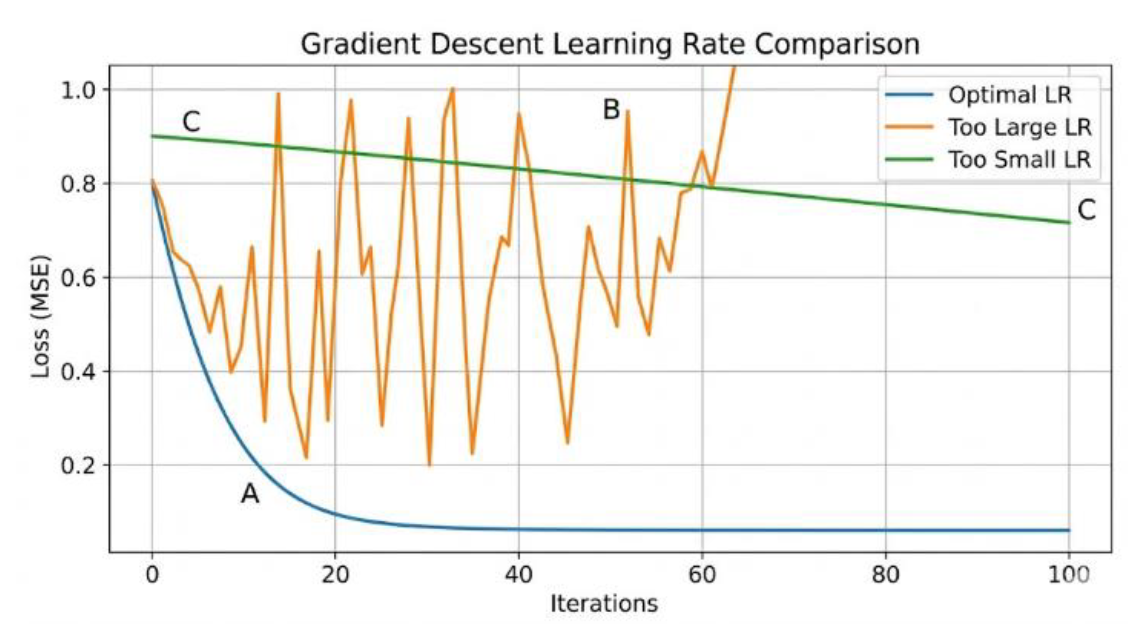

Dựa trên đồ thị, hãy trả lời các câu hỏi sau:

#### 11.1. Quan sát Đường cong A (màu xanh lá cây) và Đường cong B (màu cam). Giải thích tại sao đường A giảm rất chậm trong khi đường B lại dao động mạnh (oscillation) và cuối cùng Loss tăng vọt lên vô cùng (diverge)?



> Bởi vì learning rate của đường cong màu xanh lá cây thấp, dẫn đến cần nhiều iterations để converge. Đường cong B có learning rate cao khiến cho tham số của model mỗi lần hiệu chỉnh phản ánh tệ hơn trước hơn hiệu chỉnh (loss bị dao động sau các lần hiệu chỉnh), dẫn đến diverge.



#### 11.2. Kết nối các đường cong với Learning Rate phù hợp: Đường nào tương ứng với Learning Rate quá nhỏ? Đường nào tương ứng với Learning Rate quá lớn? Và đường nào là Learning Rate tối ưu? Nêu lý do cho từng lựa chọn



> Đường cong A (xanh dương): learning rate tối ưu, loss đạt minium sau ít lần iterations nhất trong 3 đường
> Đường cong B (cam): learning rate quá cao, Loss bị dao động mạnh và dần dẫn đến diverge
> Đường cong C (xanh lá): learning rate thấp, loss dần đạt minium nhưng sau nhiều lần iterations


#### 11.3. Nếu bạn muốn triển khai tính năng Tự động điều chỉnh Tốc độ học (Auto-tuning), bạn sẽ dựa vào tín hiệu nào từ đồ thị Loss để quyết định giảm Tốc độ học? Đề xuất một giả mã (pseudocode) ngắn gọn cho logic này


```md
Chọn Learning Rate ban đầu bằng cách tăng dần từ giá trị nhỏ và chọn mức mà Training Loss giảm nhanh, ổn định, trước khi dao động. Khi train, nếu Validation Loss không cải thiện sau vài epoch thì giảm Learning Rate.
```

```c
learning_rate = find_initial_learning_rate()
min_loss = infinity
wait = 0
patience = 5

FOR each epoch:
    train_one_epoch(learning_rate)
    validation_loss = evaluate_validation_loss()

    IF validation_loss < min_loss:
        min_loss = validation_loss
        wait = 0
    ELSE:
        wait++

    IF wait >= patience:
        learning_rate = learning_rate * decrease_rate
        wait = 0
```


---
### 12. Bài 12 - Learning Curve

Bạn đang xây dựng một mô hình MLP phức tạp để dự báo độ chính xác của GPS dựa trên số lượng vệ tinh, cường độ tín hiệu và độ cao. Đồ thị dưới đây mô tả sai số (Error) trên tập Training (xanh) và tập Validation (cam) khi thay đổi Kích thước tập dữ liệu huấn luyện (Training Set Size).

Dựa trên đồ thị, hãy trả lời các câu hỏi sau:

#### 12.1. Mô tả khoảng cách (gap) giữa hai đường Training Error và Validation Error. Điều này cho biết mô hình đang bị hiện tượng High Bias (Underfitting) hay High Variance (Overfitting)? Hãy giải thích lý do cụ thể dựa trên đồ thị



> Khoảng cách giữa 2 đường nhỏ dần, tuy nhiên vẫn duy trì một gap lớn sau khi train. Mô hình đang bị High Vairance, lý do là model fit với train data nhưng mà kém chính xác hơn nhiều đối với validation data.


#### 12.2. Tại sao khi kích thước tập dữ liệu huấn luyện tăng lên, Training Error lại tăng nhưng Validation Error lại giảm? Hãy giải thích cơ chế của hiện tượng này


> Training data ban đầu bắt đầu bằng 0 do model fit hoàn toàn với tệp data đầu vào. Tuy nhiên tính chất của data luôn có nhiễu, cũng như chưa chắc model được lựa chọn là phù hợp nhất với loại data nên càng train thì training error sẽ tăng lên.
> Ngược lại, cằng train nhiều data thì model càng thích nghi hơn, dẫn đến việc validation error giảm.


#### 12.3. Nếu mục tiêu là giảm khoảng cách giữa hai đường, bạn nên thực hiện giải pháp nào trong 2 giải pháp sau:

- (A) Thu thập thêm thật nhiều dữ liệu huấn luyện (Data augmentation/Data collection).
- (B) Sử dụng Regularization (ví dụ: Ridge, Lasso) hoặc đơn giản hóa cấu trúc mô hình (giảm số lượng tham số).

Nêu lý do giải thích cho lựa chọn của bạn dựa trên đồ thị đã cho.



> B. lí do rằng model cằng phức tạp và càng có nhiều tham số thì sẽ càng overfit train data. Việc giảm độ phức tạp cũng như giảm tỉ trọng của các tham số kém quan trọng làm tăng độ thích nghi của model đối với nhiều nguồn data.



---
### 13. Bài 13 - Auto-tuning Learning Rate

Một kỹ sư đang điều chỉnh tham số cho thuật toán Gradient Descent để hiệu chuẩn cảm biến IMU. Đồ thị dưới đây mô tả 3 kịch bản của Learning Rate ($\eta$).

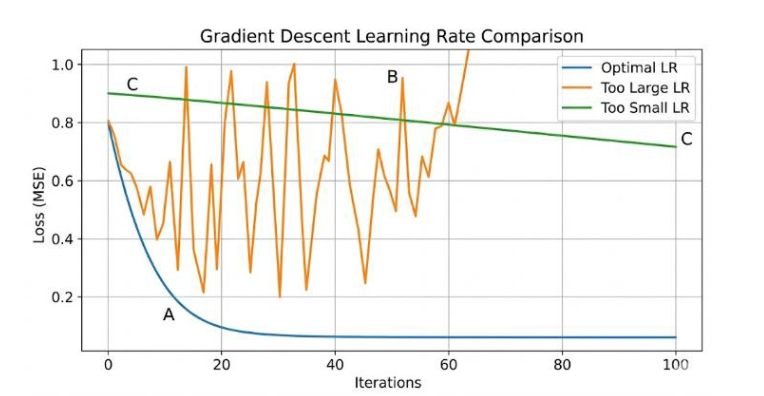


#### 13.1. Đường A giảm rất chậm, gần như đi ngang. Điều này cho thấy Learning Rate đang quá lớn hay quá nhỏ? Hệ quả về thời gian huấn luyện là gì?





> Learning rate quá nhỏ, khiến model cần nhiều iterations hơn để đạt minium loss. Hệ quả là càng nhiều thời gian để huấn luyện hơn


#### 13.2. Đường B dao động mạnh (oscillation) và cuối cùng Loss tăng vọt lên vô cùng. Giải thích hiện tượng này dưới góc độ toán học



> Công thức cập nhật là $w^{(k+1)}=w^{(k)}-\eta\dfrac{dJ}{dw}(w^{(k)})$. Khi $\eta$ quá lớn, mỗi lần cập nhật sẽ làm $w$ nhảy qua điểm minimum thay vì tiến dần tới nó. Các bước nhảy ngày càng lớn làm Loss dao động và sau đó diverge.


#### 13.3. Nếu bạn muốn triển khai tính năng Auto-tuning trên vi điều khiển để tự tìm Learning Rate tối ưu, bạn sẽ dựa vào tín hiệu nào từ đồ thị Loss để quyết định giảm $\eta$?



> Nếu Loss tăng hoặc dao động liên tục sau một số lần lặp thì learning rate đang quá lớn. Khi đó có thể giảm $\eta$, ví dụ giảm còn một nửa, rồi tiếp tục train.



---
### 14. Bài 14 - Lựa chọn hệ số Ridge

Giả sử bạn huấn luyện một mô hình Ridge Regression trên tập dữ liệu 1000 mẫu.

Cho các kết quả:

- $\lambda=0.001$: Training Loss = 0.05, Validation Loss = 0.50.
- $\lambda=10$: Training Loss = 0.15, Validation Loss = 0.18.
- $\lambda=1000$: Training Loss = 0.80, Validation Loss = 0.82.

#### 14.1. Hãy nhận xét về trạng thái mô hình (Underfitting, Overfitting hay Just Right) tại mỗi giá trị $\lambda$


```
> 1. $\lambda=0.001$: Gap giữa traning loss và validation loss quá lớn, model đang bị overfitting.
> 2. $\lambda=10$: Training Loss và validation Loss đều thấp và gần nhau, đây là mức Just Right.
> 3. $\lambda=1000$: Cả hai loss đều cao, model đang bị underfitting.
```

#### 14.2. Giải thích tại sao khi $\lambda$ tăng, Training Loss lại tăng nhưng mô hình lại có thể tốt hơn cho thực tế?



> Khi $\lambda$ tăng, các hệ số $w$ bị ép nhỏ hơn nên model không còn fit quá sát training data, làm Training Loss tăng. Tuy nhiên model sẽ ít nhạy với nhiễu và các dữ liệu riêng của tập train, nên Validation Loss có thể giảm và khả năng generalization tốt hơn.


---
### 15. Bài 15 - So sánh các hàm mất mát

Trong bài toán hồi quy, tại sao đôi khi người ta ưu tiên sử dụng Huber Loss thay vì MSE (Mean Squared Error) hoặc MAE (Mean Absolute Error)? Hãy viết công thức MSE, MAE, Huber Loss và giải thích cơ chế "chuyển đổi" của nó.



> Công thức của MSE và MAE:
>
> $$MSE=\frac{1}{n}\sum_{i=1}^{n}e_i^2$$
>
> $$MAE=\frac{1}{n}\sum_{i=1}^{n}|e_i|$$
>
> Huber Loss cho một sai số $e$:
>
> $$L_\delta(e)=\begin{cases}\frac{1}{2}e^2,&|e|\leq\delta\\\delta\left(|e|-\frac{1}{2}\delta\right),&|e|>\delta\end{cases}$$
>
> Với sai số nhỏ, Huber dùng dạng bình phương giống MSE để tối ưu mượt quanh điểm minimum. Với sai số lớn, Loss tăng tuyến tính giống MAE nên outlier không gây ra gradient quá lớn. Vì vậy Huber ít nhạy với nhiễu hơn MSE nhưng vẫn dễ tối ưu hơn MAE tại $e=0$.


---
### 16. Bài 16 - Hình dáng Huber Loss

Hãy vẽ phác thảo (hoặc mô tả) hình dáng đồ thị của Huber Loss so với MSE. Tại sao nói Huber Loss kết hợp được ưu điểm của cả MSE và MAE?



> MSE có dạng parabol và tăng rất nhanh khi $|e|$ lớn. Huber Loss cũng có dạng parabol gần $e=0$, nhưng sau ngưỡng $\delta$ thì chuyển sang đường thẳng. Vì vậy Huber vẫn nhạy với sai số nhỏ như MSE, nhưng giảm ảnh hưởng của outlier giống MAE.


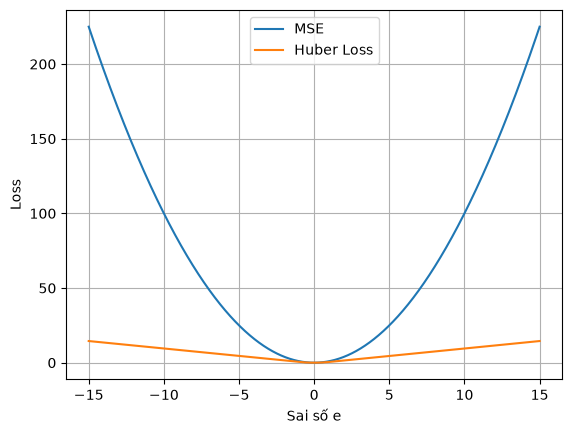

In [203]:
import numpy as np
import matplotlib.pyplot as plt

e = np.linspace(-15, 15, 4000)
delta = 1

mse_loss = e ** 2
huber_loss = np.where(
    np.abs(e) <= delta,
    0.5 * e ** 2,
    delta * (np.abs(e) - 0.5 * delta)
)

plt.plot(e, mse_loss, label="MSE")
plt.plot(e, huber_loss, label="Huber Loss")
plt.xlabel("Sai số e")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

---
### 17. Bài 17 - L1 và L2 Regularization

Phân biệt L1 Regularization (Lasso) và L2 Regularization (Ridge):

#### 17.1. Viết hàm mất mát của Linear Regression khi có thêm thành phần L1 và L2



> Với Lasso (L1):
>
> $$J_{L1}(w)=MSE+\lambda\sum_{j=1}^{p}|w_j|$$
>
> Với Ridge (L2):
>
> $$J_{L2}(w)=MSE+\lambda\sum_{j=1}^{p}w_j^2$$


#### 17.2. Tại sao Lasso Regression lại có khả năng thực hiện Feature Selection (loại bỏ các đặc trưng không quan trọng) trong khi Ridge Regression thì không?



> Lasso phạt hệ số với một mức gần như cố định nên có thể kéo hệ số về đúng 0. Ridge phạt theo độ lớn hiện tại của hệ số, nên khi hệ số càng nhỏ thì mức phạt càng giảm. Vì vậy Ridge thường chỉ làm hệ số gần 0 chứ không bằng 0.


#### 17.3. Trong trường hợp dữ liệu có các biến độc lập tương quan mạnh với nhau (Multicollinearity), bạn sẽ ưu tiên dùng Ridge hay Lasso? Tại sao?



> Tôi sẽ ưu tiên Ridge nếu muốn giữ lại các biến đang tương quan. Ridge chia ảnh hưởng giữa các biến và làm các hệ số ổn định hơn. Lasso có thể giữ một biến và loại các biến còn lại


---
### 18. Bài 18 - Vai trò của λ

Tham số $\lambda$ (hay alpha trong Scikit-learn) đóng vai trò gì trong Regularization? Điều gì xảy ra với mô hình nếu $\lambda\to0$ và khi $\lambda\to\infty$?



> $\lambda$ quy định mức độ phạt các hệ số lớn. Khi $\lambda\to0$, thành phần phạt gần như biến mất và model trở về Linear Regression thông thường. Khi $\lambda\to\infty$, các hệ số bị ép về gần 0, model trở nên quá đơn giản.


---
### 19. Bài 19 - OLS và HuberRegressor

Bạn có một cảm biến áp suất được thu thập dữ liệu qua bộ ADC của vi điều khiển. Do nhiễu điện từ, tập dữ liệu có một vài điểm bị "vọt" (outliers) rất lớn. Nếu dùng OLS thông thường, đường hiệu chuẩn sẽ bị lệch.


#### 19.1. Khởi tạo một tập dữ liệu giả lập có 50 mẫu theo công thức $y=3.5x+10+\epsilon$

In [204]:
import numpy as np

rng = np.random.default_rng()

x_values = []

for i in range(50):
    x_values.append(0 + i)

X = np.array(x_values).reshape(-1, 1)
epsilon = rng.normal(0, 8, 50)
y = 3.5 * X.ravel() + 10 + epsilon

print(f"len = {len(y)}")
print(y)


len = 50
[ 12.23354601  20.80554605  19.24632356  24.13373432  19.85044159
  37.11420777  47.26763521  29.53920332  36.39375455  41.66118115
  42.002734    30.68153362  44.81767101  58.23615392  63.43700144
  73.46940605  53.25454221  80.21318275  61.07937516  67.17695353
  71.26592764  86.04692542  88.03997451  85.8337008   84.62840267
  89.31803932  97.02244399  92.63915665 111.17942481 112.07198433
 100.86794313 112.84308186 118.19645556 116.75721092 127.69144919
 136.41784231 142.48921796 133.74903005 152.92505499 140.70520512
 144.10545112 153.70769062 154.34045843 148.86634761 167.39340263
 170.54377862 176.08394618 167.79567132 193.00638793 191.20948791]


#### 19.2. Trong tập dữ liệu vừa tạo, cố tình thay đổi 5 mẫu cuối cùng thành các giá trị nhiễu cực lớn (ví dụ $y=500$)




In [205]:
y_noisy = y.copy()
y_noisy[-5:] = 500

#### 19.3. Sử dụng LinearRegression (OLS) và HuberRegressor từ Scikit-learn để huấn luyện trên cùng tập dữ liệu này


In [206]:
from sklearn.linear_model import LinearRegression, HuberRegressor

ols = LinearRegression()
huber = HuberRegressor(max_iter=50)

ols.fit(X, y_noisy)
huber.fit(X, y_noisy)

print(f"OLS: w0 = {ols.intercept_:.2f}, w1 = {ols.coef_[0]:.2f}")
print(f"Huber: w0 = {huber.intercept_:.2f}, w1 = {huber.coef_[0]:.2f}")


OLS: w0 = -43.54, w1 = 6.95
Huber: w0 = 8.01, w1 = 3.55


#### 19.4. Vẽ đồ thị so sánh hai đường thẳng dự báo của OLS và Huber so với các điểm dữ liệu thực tế



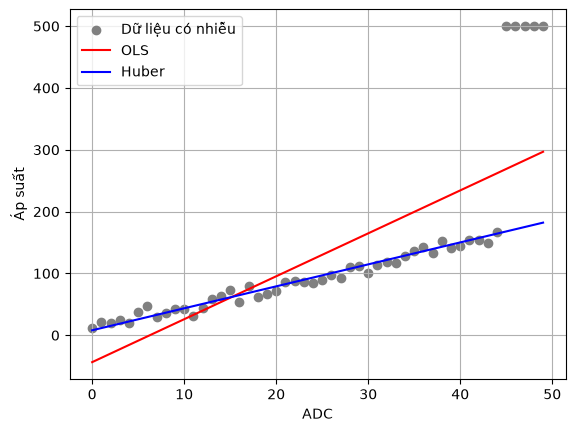

In [207]:
import matplotlib.pyplot as plt

x_line_values = []

for i in range(50):
    x_line_values.append(i)

X_line = np.array(x_line_values).reshape(-1, 1)

plt.scatter(X, y_noisy, label="Dữ liệu có nhiễu", color="gray")
plt.plot(X_line, ols.predict(X_line), label="OLS", color="red")
plt.plot(X_line, huber.predict(X_line), label="Huber", color="blue")
plt.xlabel("ADC")
plt.ylabel("Áp suất")
plt.grid(True)
plt.legend()
plt.show()


---
### 20. Bài 20 - Lasso Feature Selection

Bạn đang xây dựng mô hình dự báo tuổi thọ pin của thiết bị Edge AI. Bạn thu thập được 20 tham số đầu vào (nhiệt độ, điện áp, số chu kỳ sạc, cường độ WiFi, tốc độ quạt...). Tuy nhiên, bạn nghi ngờ chỉ có vài tham số thực sự ảnh hưởng. Bạn cần dùng Lasso để "loại bỏ" các tham số thừa nhằm tiết kiệm bộ nhớ cho MCU.


#### 20.1. Sử dụng bộ dữ liệu make_regression của Scikit-learn để tạo 100 mẫu với 20 đặc trưng, nhưng chỉ có 5 đặc trưng là thực sự có ý nghĩa ($n_{informative}=5$)



In [208]:
import numpy as np
from sklearn.datasets import make_regression

X, y, true_coef = make_regression(
    n_samples=100, n_features=20, n_informative=5, noise=10, coef=True, random_state=100
)

print("X shape =", X.shape)
print("y shape =", y.shape)

X shape = (100, 20)
y shape = (100,)


#### 20.2. Sử dụng StandardScaler để chuẩn hóa dữ liệu (quan trọng đối với Regularization)



In [209]:
from sklearn.preprocessing import StandardScaler

print("Mean =", X.mean(axis=0).round(2))
print("Std =", X.std(axis=0).round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean =", X_scaled.mean(axis=0).round(2))
print("Std =", X_scaled.std(axis=0).round(2))

Mean = [-0.06  0.05 -0.09  0.11  0.21 -0.13 -0.2   0.06 -0.17  0.07  0.08 -0.04
 -0.03  0.04 -0.18  0.12 -0.    0.08 -0.04  0.04]
Std = [0.97 0.94 0.93 0.93 1.   1.07 0.99 1.05 0.98 0.94 1.05 1.04 1.   1.08
 1.18 0.99 1.09 1.07 1.08 1.  ]

Mean = [-0.  0. -0. -0. -0. -0.  0. -0. -0. -0. -0.  0.  0. -0.  0.  0.  0.  0.
 -0.  0.]
Std = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


#### 20.3. Huấn luyện mô hình Lasso với tham số alpha=0.1



In [210]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_scaled, y)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


#### 20.4. In ra các hệ số ($w$) của mô hình



In [211]:
for i, coef in enumerate(lasso.coef_, start=1):
    print(f"w{i:02d} = {coef:.4f}")


w01 = -0.5354
w02 = 1.7440
w03 = 0.0000
w04 = 1.5744
w05 = -0.8002
w06 = 0.1222
w07 = -0.3730
w08 = 32.8008
w09 = 4.9226
w10 = 51.3307
w11 = 2.4530
w12 = 0.8122
w13 = -0.9674
w14 = -0.2027
w15 = 0.1669
w16 = -0.1790
w17 = -0.4132
w18 = 38.9808
w19 = 49.2356
w20 = -0.1442


#### 20.5. Vẽ đồ thị so sánh hai đường thẳng dự báo của OLS và Huber so với các điểm dữ liệu thực tế



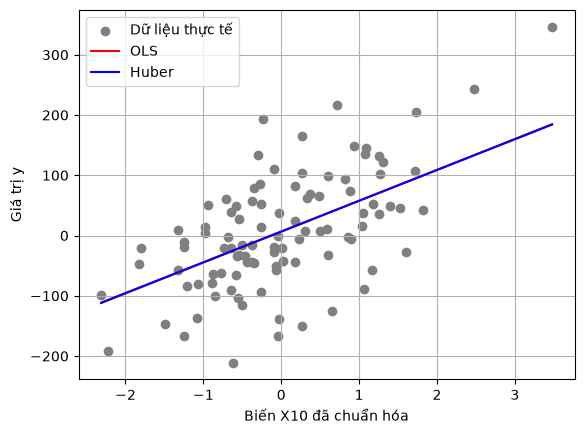

In [212]:
from sklearn.linear_model import LinearRegression, HuberRegressor

ols_20 = LinearRegression()
huber_20 = HuberRegressor(max_iter=1000)

ols_20.fit(X_scaled, y)
huber_20.fit(X_scaled, y)

feature_index = np.argmax(np.abs(ols_20.coef_))
x_feature = X_scaled[:, feature_index]

number_of_points = 100
step = (x_feature.max() - x_feature.min()) / (number_of_points - 1)
x_line = []

for i in range(number_of_points):
    x_line.append(x_feature.min() + i * step)

x_line = np.array(x_line)
X_line = np.zeros((number_of_points, X_scaled.shape[1]))
X_line[:, feature_index] = x_line

y_ols_line = ols_20.predict(X_line)
y_huber_line = huber_20.predict(X_line)

plt.scatter(x_feature, y, label="Dữ liệu thực tế", color="gray")
plt.plot(x_line, y_ols_line, label="OLS", color="red")
plt.plot(x_line, y_huber_line, label="Huber", color="blue")
plt.xlabel(f"Biến X{feature_index + 1} đã chuẩn hóa")
plt.ylabel("Giá trị y")
plt.grid(True)
plt.legend()
plt.show()


#### 20.6. So sánh hệ số của Linear Regression và Lasso



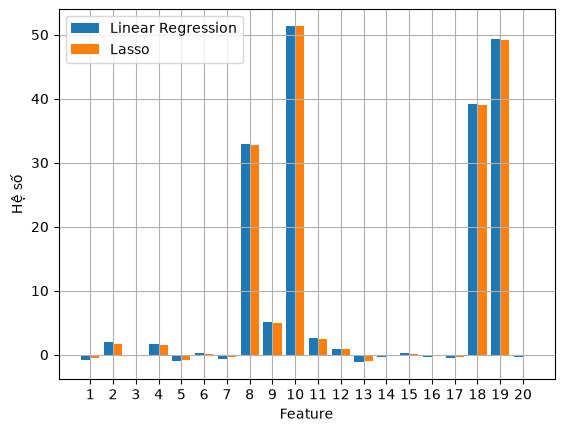

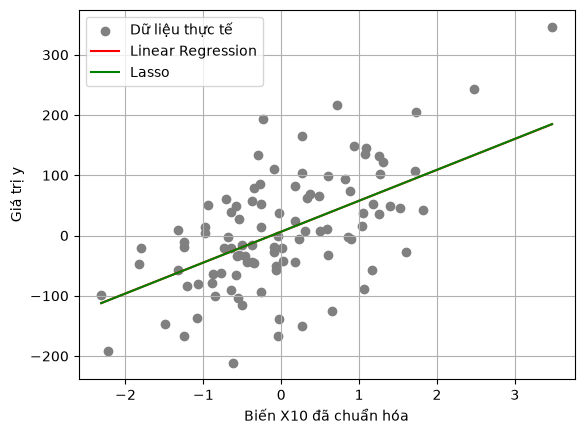

: 

In [ ]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_scaled, y)

feature_index = np.arange(1, X_scaled.shape[1] + 1)

plt.bar(feature_index - 0.2, linear.coef_, width=0.4, label="Linear Regression")
plt.bar(feature_index + 0.2, lasso.coef_, width=0.4, label="Lasso")
plt.xticks(feature_index)
plt.xlabel("Feature")
plt.ylabel("Hệ số")
plt.grid(True)
plt.legend()
plt.show()

selected_feature = np.argmax(np.abs(lasso.coef_))
x_feature = X_scaled[:, selected_feature]

number_of_points = 100
step = (x_feature.max() - x_feature.min()) / (number_of_points - 1)
x_line = []

for i in range(number_of_points):
    x_line.append(x_feature.min() + i * step)

x_line = np.array(x_line)
X_line = np.zeros((number_of_points, X_scaled.shape[1]))
X_line[:, selected_feature] = x_line

y_linear_line = linear.predict(X_line)
y_lasso_line = lasso.predict(X_line)

plt.scatter(x_feature, y, label="Dữ liệu thực tế", color="gray")
plt.plot(x_line, y_linear_line, label="Linear Regression", color="red")
plt.plot(x_line, y_lasso_line, label="Lasso", color="green")
plt.xlabel(f"Biến X{selected_feature + 1} đã chuẩn hóa")
plt.ylabel("Giá trị y")
plt.grid(True)
plt.legend()
plt.show()
